# Proyecto Módulo 8 – Clasificador Inteligente de Imágenes de Ropa (Keras/TensorFlow)

Este notebook desarrolla las 4 lecciones del proyecto usando **Keras/TensorFlow**:
1. Red neuronal densa simple (clasificación binaria).
2. Discusión de arquitecturas (densa vs convolutiva).
3. Implementación de modelo denso para Fashion-MNIST.
4. Implementación de CNN para Fashion-MNIST y comparación.

Dataset: Fashion-MNIST (28x28, 10 clases de ropa).

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.21.0


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

class_names = [
    "Camiseta/top", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]

len(class_names)

10

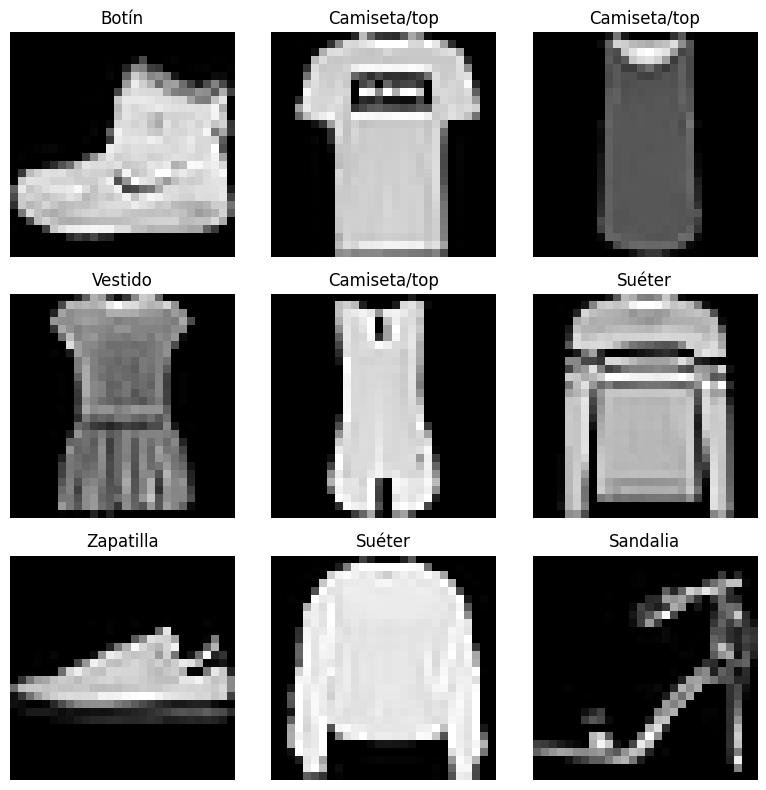

In [4]:
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
binary_train_mask = (y_train == 7) | (y_train == 9)
binary_test_mask = (y_test == 7) | (y_test == 9)

x_train_bin = x_train_flat[binary_train_mask]
y_train_bin = (y_train[binary_train_mask] == 7).astype(int)

x_test_bin = x_test_flat[binary_test_mask]
y_test_bin = (y_test[binary_test_mask] == 7).astype(int)

x_train_bin.shape, x_test_bin.shape

((12000, 784), (2000, 784))

## Lección 1 – Arquitectura de red densa (binaria)

1. **Capa de entrada**: vector de tamaño 784 (28x28 píxeles aplanados).
2. **Capa oculta densa**: por ejemplo 128 neuronas con activación ReLU.
3. **Capa de salida**: 1 neurona con activación sigmoide (da un valor entre 0 y 1 que interpretamos como probabilidad de "zapatilla").

- Función de pérdida: `binary_crossentropy` (para clasificación binaria).
- Optimizador: `adam` (simple y efectivo).
- Métrica: `accuracy`.

In [6]:
model_bin = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_bin.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model_bin.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [8]:
history_bin = model_bin.fit(
    x_train_bin,
    y_train_bin,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9233 - loss: 0.1973 - val_accuracy: 0.9446 - val_loss: 0.1427
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9532 - loss: 0.1266 - val_accuracy: 0.9533 - val_loss: 0.1226
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9595 - loss: 0.1121 - val_accuracy: 0.9513 - val_loss: 0.1276
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9656 - loss: 0.0973 - val_accuracy: 0.9671 - val_loss: 0.1066
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9678 - loss: 0.0878 - val_accuracy: 0.9646 - val_loss: 0.1064
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9686 - loss: 0.0830 - val_accuracy: 0.9654 - val_loss: 0.0984
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9693 - loss: 0.0788 - val_accuracy: 0.9688 - val_loss: 0.1000
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9709 - loss: 0.0793 - val_accuracy: 0.9633 - val_loss:

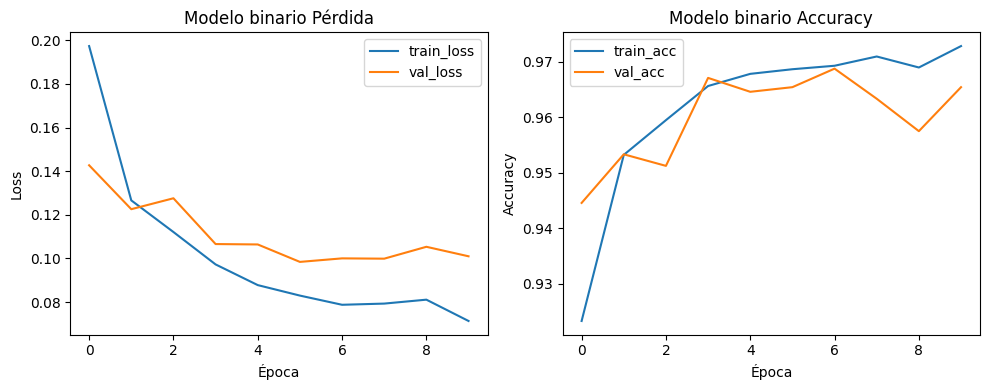

In [9]:
def plot_history(h, title_prefix=""):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(h.history["loss"], label="train_loss")
    plt.plot(h.history["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Pérdida")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h.history["accuracy"], label="train_acc")
    plt.plot(h.history["val_accuracy"], label="val_acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_bin, title_prefix="Modelo binario")

In [10]:
test_loss_bin, test_acc_bin = model_bin.evaluate(x_test_bin, y_test_bin, verbose=0)
print("Pérdida (test):", test_loss_bin)
print("Accuracy (test):", test_acc_bin)

idx = 0
sample = x_test_bin[idx:idx+1]
pred_prob = model_bin.predict(sample)[0, 0]
pred_label = int(pred_prob >= 0.5)
print("Prob. zapatilla:", pred_prob)
print("Predicción (1=zapatilla,0=botín):", pred_label)
print("Etiqueta real:", y_test_bin[idx])

Pérdida (test): 0.09681724011898041
Accuracy (test): 0.9660000205039978
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prob. zapatilla: 0.024274893
Predicción (1=zapatilla,0=botín): 0
Etiqueta real: 0


## Lección 2 – Red densa vs CNN

- **Red densa**: conecta todas las neuronas de una capa con todas las de la siguiente, no aprovecha la estructura espacial de la imagen.
- **CNN**: usa filtros pequeños que se desplazan sobre la imagen, detectando patrones locales y reutilizándolos en toda la imagen.

Usaremos un modelo denso como línea base y una CNN para mejorar el desempeño y compararlos.

In [11]:
model_dense = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model_dense.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model_dense.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [13]:
history_dense = model_dense.fit(
    x_train_flat,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    verbose=1
)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7456 - loss: 0.7175 - val_accuracy: 0.8372 - val_loss: 0.4428
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8339 - loss: 0.4621 - val_accuracy: 0.8543 - val_loss: 0.3936
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8523 - loss: 0.4107 - val_accuracy: 0.8673 - val_loss: 0.3672
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8602 - loss: 0.3863 - val_accuracy: 0.8759 - val_loss: 0.3496
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8665 - loss: 0.3626 - val_accuracy: 0.8664 - val_loss: 0.3619
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8730 - loss: 0.3501 - val_accuracy: 0.8808 - val_loss: 0.3320
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8761 - loss: 0.3394 - val_accuracy: 0.8849 - val_loss: 0.3219
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8801 - loss: 0.3270 - val_accuracy: 0.

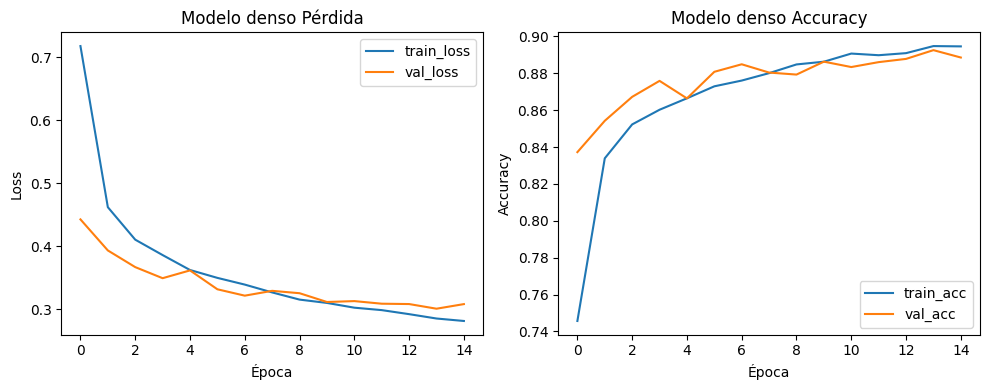

Pérdida (test) denso: 0.33641940355300903
Accuracy (test) denso: 0.8820000290870667


In [14]:
plot_history(history_dense, title_prefix="Modelo denso")

test_loss_dense, test_acc_dense = model_dense.evaluate(x_test_flat, y_test, verbose=0)
print("Pérdida (test) denso:", test_loss_dense)
print("Accuracy (test) denso:", test_acc_dense)

In [15]:
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]

x_train_cnn.shape, x_test_cnn.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [16]:
model_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_cnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    verbose=1
)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7403 - loss: 0.7146 - val_accuracy: 0.8342 - val_loss: 0.4666
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8341 - loss: 0.4571 - val_accuracy: 0.8618 - val_loss: 0.3914
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8539 - loss: 0.4039 - val_accuracy: 0.8725 - val_loss: 0.3591
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8640 - loss: 0.3747 - val_accuracy: 0.8796 - val_loss: 0.3346
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8725 - loss: 0.3505 - val_accuracy: 0.8849 - val_loss: 0.3132
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.8791 - loss: 0.3294 - val_accuracy: 0.8906 - val_loss: 0.2977
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8849 - loss: 0.3150 - val_accuracy: 0.8938 - val_loss: 0.2907
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8893 - loss: 0.3028 - val_accu

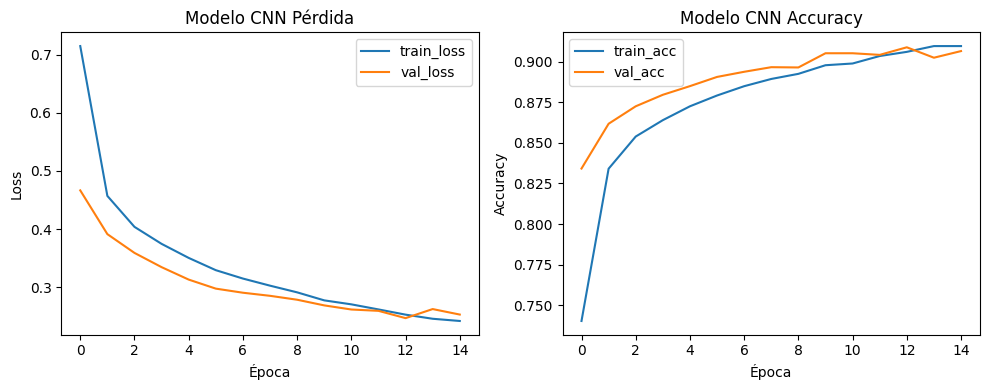

Pérdida (test) CNN: 0.2664179801940918
Accuracy (test) CNN: 0.9032999873161316
Accuracy denso vs CNN: 0.8820000290870667 vs 0.9032999873161316


In [18]:
plot_history(history_cnn, title_prefix="Modelo CNN")

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test, verbose=0)
print("Pérdida (test) CNN:", test_loss_cnn)
print("Accuracy (test) CNN:", test_acc_cnn)
print("Accuracy denso vs CNN:", test_acc_dense, "vs", test_acc_cnn)

In [21]:
from PIL import Image

def predict_external_image(path, model, use_cnn=True):
    img = Image.open(path).convert("L").resize((28, 28))
    img_array = np.array(img).astype("float32") / 255.0

    if use_cnn:
        img_array = img_array[np.newaxis, ..., np.newaxis]
    else:
        img_array = img_array.reshape(1, 28 * 28)

    probs = model.predict(img_array)[0]
    pred_class = int(np.argmax(probs))
    print("Predicción:", class_names[pred_class])
    print("Probabilidades:", probs)

# Ejemplo de uso:
predict_external_image("botin.png", model_cnn, use_cnn=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicción: Botín
Probabilidades: [8.9246992e-09 2.2099282e-09 1.3354317e-08 5.6066649e-09 1.6459734e-09
 1.4764532e-05 8.3074125e-09 3.8515108e-03 6.0968314e-06 9.9612767e-01]
